In [1]:
# --- INSTALLATION ---
# python -m venv .venv
# .venv\Scripts/activate
# pip install ipykernel dotenv pandas seaborn matplotlib

<h1> Setting Up </h1>

In [2]:
import json
import os
import ssl
import urllib.parse
import urllib.request
from pathlib import Path

import certifi
from dotenv import load_dotenv

import pandas as pd

from time import time
from time import sleep

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load API key
load_dotenv(Path.cwd().parent / ".env")
API_KEY = os.getenv("CMC_API_KEY")
if not API_KEY:
    raise ValueError("CMC_API_KEY is missing.")

# Fetch Data
params = urllib.parse.urlencode(
    {
        "start": "1",
        "limit": "5000",
        "convert": "USD",
    }
)

request = urllib.request.Request(
    f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
    headers={
        "Accept": "application/json",
        "X-CMC_PRO_API_KEY": API_KEY,
    },
)

context = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(request, context=context) as response:
    data = json.load(response)
print(data)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20087803, 'total_supply': 20087803, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12751, 'cmc_rank': 1, 'last_updated': '2026-09-22T06:30:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1714297481682.95, 'quote': {'USD': {'price': 85340.2177272919, 'volume_24h': 59786620337.71313, 'cex_volume_24h': 59628205872.036415, 'dex_volume_24h': 158414465.67671722, 'volume_change_24h': 173.9826, 'percent_change_1h': 0.16454926, 'percent_change_24h': 4.32633749, 'percent_change_7d': 10.26037105, 'percent_change_30d': 11.83989346, 'percent_change_60d': 30.60009386, 'percent_change_90d': 35.96045299, 'market_cap': 1714297481682.9475, 'market_cap_dominance': 59.1685, 'fully_diluted_market_cap': 1792144572273.13, 'tvl': None, 'last_updated': '202

In [4]:
# Convert to Dataframe
pd.set_option('display.max_column', None) # see all columns

df = pd.json_normalize(data['data'])

# Add Collected Time
df['collected_time'] = pd.to_datetime('now')

<h1> Automation</h1>

In [5]:
def run_api():
    global df
    
    # Load API key
    load_dotenv(Path.cwd().parent / ".env")
    API_KEY = os.getenv("CMC_API_KEY")
    if not API_KEY:
        raise ValueError("CMC_API_KEY is missing.")

    # Fetch Data
    params = urllib.parse.urlencode(
        {
            "start": "1",
            "limit": "200", # 200 for faster runs tests
            "convert": "USD",
        }
    )

    request = urllib.request.Request(
        f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
        headers={
            "Accept": "application/json",
            "X-CMC_PRO_API_KEY": API_KEY,
        },
    )

    context = ssl.create_default_context(cafile=certifi.where())
    with urllib.request.urlopen(request, context=context) as response:
        data = json.load(response)
    print(data)
    # Convert to Dataframe
    pd.set_option('display.max_column', None) # see all columns

    df_auto = pd.json_normalize(data['data'])

    # Add Collected Time
    df_auto['collected_time'] = pd.to_datetime('now')
    # Append to df
    df = pd.concat([df, df_auto])
    
    # Export to CSV
    load_dotenv(Path.cwd().parent / ".env")
    DATA_PATH = os.getenv("DATA_PATH")
    if not API_KEY:
        raise ValueError("DATA_PATH is missing.")
    if not os.path.isfile(rf'{DATA_PATH}\crypto_api.csv'):
        df.to_csv(rf'{DATA_PATH}\crypto_api.csv', header=list(df.columns.values), index=False)
    else:
        df.to_csv(rf'{DATA_PATH}\crypto_api.csv', mode='a', header=False, index=False)
    # Read back into df
    df = pd.read_csv(rf'{DATA_PATH}/crypto_api.csv')

In [6]:
for i in range(5):
    run_api()
    print('Completed')
    sleep(60) # Sleep for 1 minute, only for pratice demonstration.
# exit()

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20087803, 'total_supply': 20087803, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12751, 'cmc_rank': 1, 'last_updated': '2026-09-22T06:30:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1714297481682.95, 'quote': {'USD': {'price': 85340.2177272919, 'volume_24h': 59786620337.71313, 'cex_volume_24h': 59628205872.036415, 'dex_volume_24h': 158414465.67671722, 'volume_change_24h': 173.9826, 'percent_change_1h': 0.16454926, 'percent_change_24h': 4.32633749, 'percent_change_7d': 10.26037105, 'percent_change_30d': 11.83989346, 'percent_change_60d': 30.60009386, 'percent_change_90d': 35.96045299, 'market_cap': 1714297481682.9475, 'market_cap_dominance': 59.1685, 'fully_diluted_market_cap': 1792144572273.13, 'tvl': None, 'last_updated': '202

<h1> Transform Data </h1>

In [7]:
# load_dotenv(Path.cwd().parent / ".env")
# DATA_PATH = os.getenv("DATA_PATH")
# df = pd.read_csv(rf'{DATA_PATH}/crypto_api.csv')

In [8]:
pd.set_option('display.float_format', lambda x: f'{x:,.5f}')

df.head(3)

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,collected_time
0,1,Bitcoin,BTC,bitcoin,False,"20,087,400.00000","20,087,400.00000","21,000,000.00000",2010-07-13T00:00:00.000Z,12751,1,2026-09-21T10:39:00.000Z,NaN,NaN,NaN,NaN,"1,690,685,838,517.95996","['mineable', 'pow', 'sha-256', 'store-of-value...","84,166.48439","35,791,410,421.61243","35,691,396,674.60812","100,013,747.00432",66.13910,-1.10896,4.78459,8.04639,9.21938,28.03526,35.23338,"1,690,685,838,517.95679",58.88470,"1,767,496,172,171.46997",NaN,2026-09-21T10:39:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-21 17:40:36.477623
1,1027,Ethereum,ETH,ethereum,True,"122,067,645.91890","122,067,645.91890",NaN,2015-08-07T00:00:00.000Z,13633,2,2026-09-21T10:38:00.000Z,NaN,NaN,NaN,NaN,"331,091,204,711.81000","['pos', 'smart-contracts', 'ethereum-ecosystem...","2,712.35840","18,367,219,830.94472","18,051,983,730.29370","315,236,100.65102",95.92190,-0.92818,5.38318,7.80739,12.55851,40.67524,64.36221,"331,091,204,711.81409",11.52060,"331,091,204,711.81000",NaN,2026-09-21T10:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-21 17:40:36.477623
2,825,Tether USDt,USDT,tether,True,"183,384,649,781.69385","189,327,421,037.88049",NaN,2015-02-25T00:00:00.000Z,201351,3,2026-09-21T10:38:00.000Z,NaN,NaN,NaN,NaN,"189,285,686,910.63000","['stablecoin', 'asset-backed-stablecoin', 'usd...",0.99978,"84,260,560,764.52310","82,703,140,037.74925","1,557,420,726.77392",42.80710,-0.00165,0.01608,0.02787,-0.00248,0.03406,0.10430,"183,344,225,640.97284",6.38570,"189,285,686,910.63000",NaN,2026-09-21T10:38:00.000Z,"1,027.00000",ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-09-21 17:40:36.477623


In [9]:
df_1 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h', 'quote.USD.percent_change_24h','quote.USD.percent_change_7d', 'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d', 'quote.USD.percent_change_90d']].median()

# Convert to pivot table
df_1 = df_1.stack()
df_1 = df_1.to_frame(name='values')

# Add index
df_1 = df_1.reset_index()

df_1 = df_1.rename(columns={'level_1': 'change_percentage'})

# Shorten change_percentage values
df_1['change_percentage'] = df_1['change_percentage'].str.split('_').str[-1]

df_1

,name,change_percentage,values
0,Bitcoin,1h,-1.10896
1,Bitcoin,24h,4.78459
2,Bitcoin,7d,8.04639
3,Bitcoin,30d,9.21938
4,Bitcoin,60d,28.03526
...,...,...,...
30559,Dogeus Maximus,24h,-4.40423
30560,Dogeus Maximus,7d,-17.68481
30561,Dogeus Maximus,30d,-62.51620
30562,Dogeus Maximus,60d,-74.26032


In [10]:
df_2 = df.loc[df['name'] == 'Bitcoin', ['name', 'quote.USD.price', 'collected_time']]
df_2

,name,quote.USD.price,collected_time
0,Bitcoin,"84,166.48439",2026-09-21 17:40:36.477623
5000,Bitcoin,"84,166.48439",2026-09-21 17:40:37.518746
5200,Bitcoin,"84,166.48439",2026-09-21 17:40:36.477623
10200,Bitcoin,"84,166.48439",2026-09-21 17:40:37.518746
10400,Bitcoin,"84,166.48439",2026-09-21 17:41:40.256425
...,...,...,...
1547600,Bitcoin,"85,340.21773",2026-09-22 13:32:25.155854
1547800,Bitcoin,"85,330.09171",2026-09-22 13:33:28.757572
1548000,Bitcoin,"85,415.58002",2026-09-22 13:34:36.581719
1548200,Bitcoin,"85,477.23480",2026-09-22 13:35:48.712379


<h1> Visualization </h1>

In [11]:
# --- Change Options ---
# Change fonts due to characters outside of unicode
plt.rcParams["font.family"] = "Microsoft YaHei"
# embedd plots as static images
%matplotlib inline
# Change sizing
plt.rcParams['figure.figsize']=(24,8)

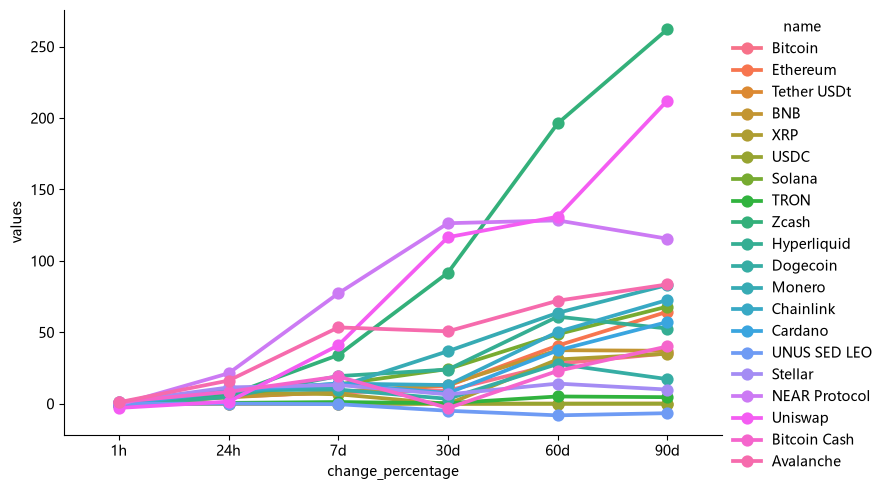

In [12]:
# Get top 20 data
top20 = df_1['name'].unique()[:20]
top20data = df_1[df_1['name'].isin(top20)]

sns.catplot(x='change_percentage', y='values', hue='name', data=top20data, kind='point', aspect=1.5)

<Axes: xlabel='collected_time', ylabel='quote.USD.price'>

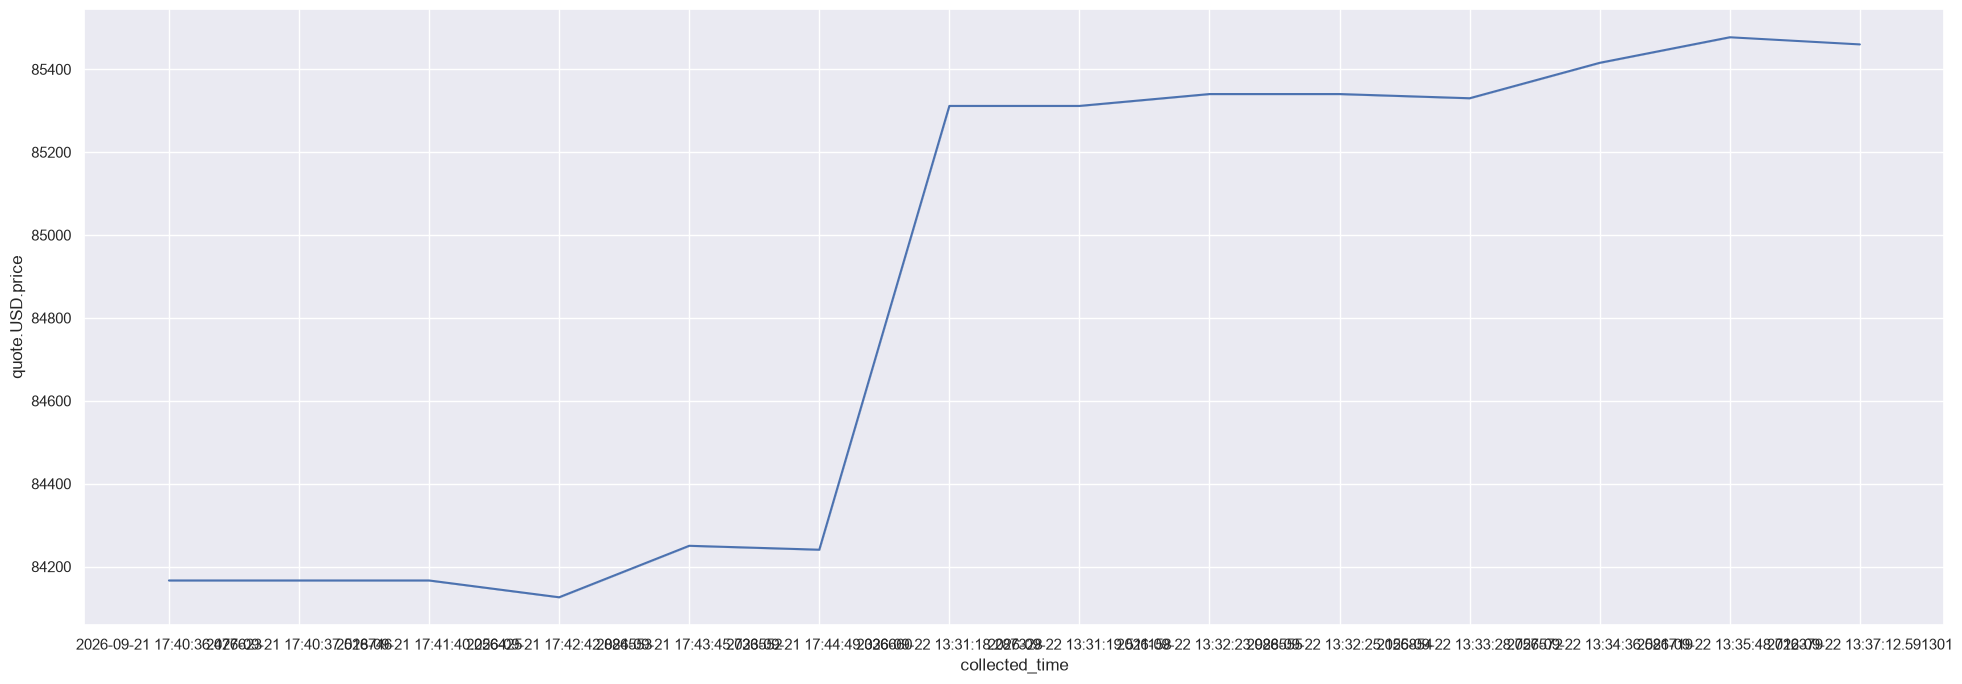

In [13]:
sns.set_theme(style='darkgrid')

sns.lineplot(x='collected_time', y='quote.USD.price', data=df_2)